In [3]:
import os

# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

from sklearn.decomposition import NMF
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from collections import defaultdict
import gffutils 

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/GeneExpression


In [4]:
# Set up paths for files 
gene_exp_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_2025-04-27.h5ad"  
ge_adata = ad.read_h5ad(gene_exp_file)

In [5]:
ge_adata.layers

Layers with keys: length_norm, log_norm, raw_counts

In [6]:
# Extract the non-negative matrix
X = ge_adata.layers["log_norm"]

# If it's a sparse matrix, densify it first
if not isinstance(X, np.ndarray):
    X = X.toarray()

print(X.shape)  # (n_cells, n_genes)

(88409, 30340)


In [7]:
# For now X = np.nan_to_num(X, nan=0.0)
X = np.nan_to_num(X, nan=0.0)

In [8]:
X.shape

(88409, 30340)

In [9]:
from sklearn.decomposition import MiniBatchNMF

n_components = 50

nmf_model = MiniBatchNMF(
    n_components=n_components,
    init="nndsvda",         
    batch_size=1024,       
    max_iter=100,         
    random_state=0,
    tol=1e-3,              
    verbose=1,             
)

W = nmf_model.fit_transform(X)  # Cells × Factors (n_obs × K)
H = nmf_model.components_       # Factors × Genes (K × n_vars)

# Save
ge_adata.obsm["X_NMF"] = W
ge_adata.uns["NMF_loadings"] = H

Minibatch step 1/8700: mean batch cost: 452.6891137147766
Minibatch step 2/8700: mean batch cost: 388.50704885804055, ewa cost: 388.50704885804055
Minibatch step 3/8700: mean batch cost: 396.039202462241, ewa cost: 388.59428927530894
Minibatch step 4/8700: mean batch cost: 410.1495911372995, ewa cost: 388.8439514074962
Minibatch step 5/8700: mean batch cost: 395.0022755790371, ewa cost: 388.91527958249515
Minibatch step 6/8700: mean batch cost: 389.7319853544435, ewa cost: 388.9247389955759
Minibatch step 7/8700: mean batch cost: 382.4908345431086, ewa cost: 388.8502189394813
Minibatch step 8/8700: mean batch cost: 390.1132984547984, ewa cost: 388.8648484318881
Minibatch step 9/8700: mean batch cost: 409.34835758634597, ewa cost: 389.10209663202573
Minibatch step 10/8700: mean batch cost: 405.619277189387, ewa cost: 389.2934052271025
Minibatch step 11/8700: mean batch cost: 411.6484700617107, ewa cost: 389.5523305340885
Minibatch step 12/8700: mean batch cost: 365.5790170842099, ewa co

In [ ]:
# Step 1: Compute neighbors using NMF latent space
sc.pp.neighbors(ge_adata, use_rep="X_NMF", key_added="neighbors_NMF", n_neighbors=20)
# Step 2: Compute UMAP from NMF latent space
sc.tl.umap(ge_adata, neighbors_key="neighbors_NMF", min_dist=0.3)
# Step 3: Cluster cells based on NMF space
sc.tl.leiden(ge_adata, neighbors_key="neighbors_NMF", resolution=0.8)

TypeError: umap() got an unexpected keyword argument 'key_added'

In [12]:
# Save updated gene expression anndata object 
# Define save path
today = datetime.datetime.now().strftime("%Y-%m-%d")
output_file = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_NMF_{today}.h5ad"

ge_adata.write_h5ad(output_file, compression="lzf")
print(f"Saved updated AnnData with NMF results to {output_file}")


Saved updated AnnData with NMF results to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/042025/ge_adata_matched_with_NMF_2025-04-27.h5ad


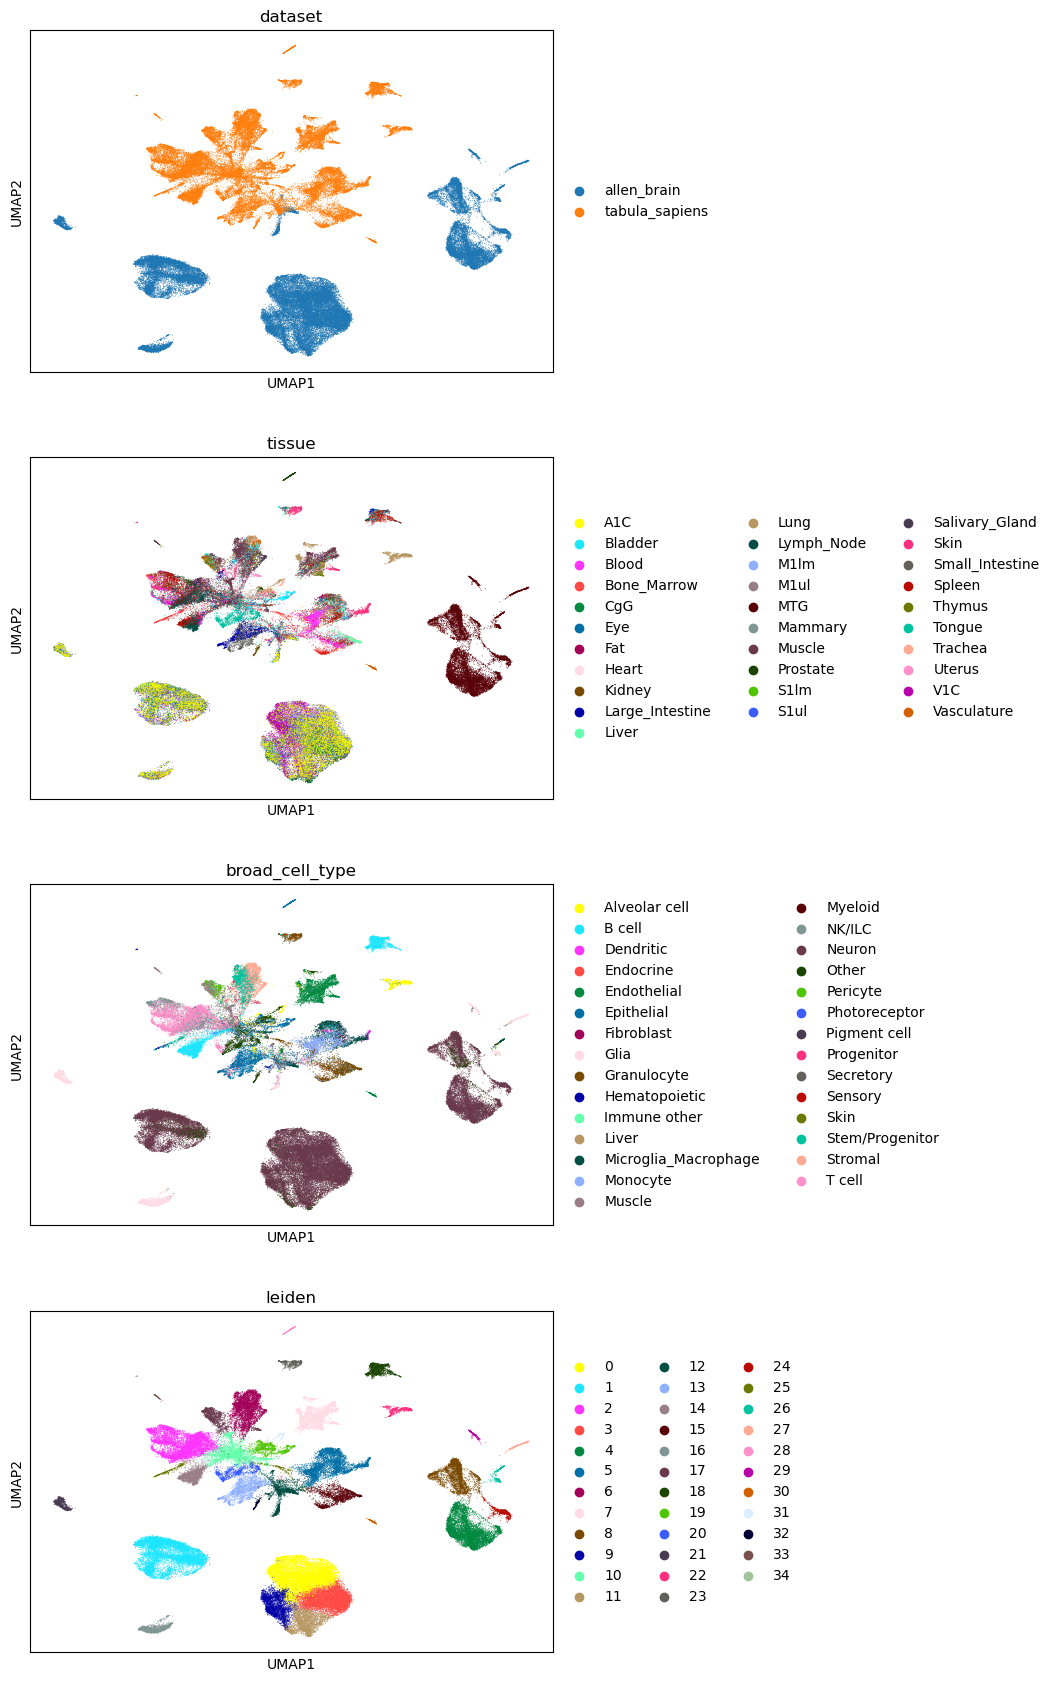

In [17]:
sc.pl.umap(
    ge_adata,
    color=["dataset", "tissue", "broad_cell_type", "leiden"],
    ncols=1
)